# Kaggle – Data on the top
Tu profe ha decidido cambiar de aires y, por eso, ha comprado una tienda de portátiles. Sin embargo, su única especialidad es Data Science, por lo que ha decidido crear un modelo de ML para establecer los mejores precios.

¿Podrías ayudar a tu profe a mejorar ese modelo?

## Métrica: RMSE

$$RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$$

Donde $y_i$ es el valor real y $\hat{y}_i$ es el valor predicho. **Cuanto menor, mejor.**

---
# PARTE 1: Entrenamiento del modelo

## 1. Librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import root_mean_squared_error, r2_score, make_scorer

## 2. Datos

In [2]:
df = pd.read_csv('./data/train.csv', encoding='latin-1')

### 2.1 Exploración de los datos

In [3]:
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 912 entries, 0 to 911
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   laptop_ID         912 non-null    int64  
 1   Company           912 non-null    str    
 2   Product           912 non-null    str    
 3   TypeName          912 non-null    str    
 4   Inches            912 non-null    float64
 5   ScreenResolution  912 non-null    str    
 6   Cpu               912 non-null    str    
 7   Ram               912 non-null    str    
 8   Memory            912 non-null    str    
 9   Gpu               912 non-null    str    
 10  OpSys             912 non-null    str    
 11  Weight            912 non-null    str    
 12  Price_in_euros    912 non-null    float64
dtypes: float64(2), int64(1), str(10)
memory usage: 203.7 KB


,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_in_euros
0,755,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i3 6006U 2GHz,8GB,256GB SSD,Intel HD Graphics 520,Windows 10,1.86kg,539.00
1,618,Dell,Inspiron 7559,Gaming,15.6,Full HD 1920x1080,Intel Core i7 6700HQ 2.6GHz,16GB,1TB HDD,Nvidia GeForce GTX 960<U+039C>,Windows 10,2.59kg,879.01
2,909,HP,ProBook 450,Notebook,15.6,Full HD 1920x1080,Intel Core i7 7500U 2.7GHz,8GB,1TB HDD,Nvidia GeForce 930MX,Windows 10,2.04kg,900.00
3,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
4,286,Dell,Inspiron 3567,Notebook,15.6,Full HD 1920x1080,Intel Core i3 6006U 2.0GHz,4GB,1TB HDD,AMD Radeon R5 M430,Linux,2.25kg,428.00


In [4]:
df.duplicated().value_counts()

False    912
Name: count, dtype: int64

### 2.2 Definir X e y


In [5]:
X = df.drop(columns="Price_in_euros").copy()

In [6]:
y = df["Price_in_euros"]

### 2.3 Dividir en train y test

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 3. Procesado de datos

> 🚨 **Data leakage:** si usas un scaler, haz **`.fit()` SOLO sobre `X_train`** y luego aplica `.transform()` sobre `X_train` y `X_test` por separado.
>
> Recuerda también que **todo lo que hagas aquí deberás replicarlo después en `test.csv`** (sección 6).

### 3.1 Feature Engineering

Extraemos **toda la señal posible** de las columnas de texto. La función `feature_engineering` se aplica idéntica a train y test (clave para no duplicar lógica). De cada columna sacamos:

- **`Cpu`** → `Cpu_tier` (i3/i5/i7/Ryzen...), `Cpu_brand`, `Cpu_GHz`, `Cpu_gen` (generación Intel)
- **`Gpu`** → `Gpu_dedicated`, `Gpu_gaming` (GTX/RTX), `Gpu_serie` (nº de serie como proxy de potencia)
- **`Memory`** → `SSD_GB`, `HDD_GB`, `Flash_GB`, `Storage_total`, `has_SSD`
- **`ScreenResolution`** → `screen_w`, `screen_h`, `pixels`, `ppi`, `Touchscreen`, `IPS`
- **Derivadas** → `weight_per_inch` (densidad), `ram_x_ssd` (interacción RAM × almacenamiento)
- **`Company`** → marcas raras (<5 muestras) agrupadas en `Other`

`Product` se descarta (408 categorías, prácticamente un identificador).

In [8]:
import re

def feature_engineering(data):
    """Feature engineering completo. Se aplica idéntico a train y test.
    Extrae toda la señal posible de las columnas de texto. No elimina filas."""
    d = data.copy()

    # --- Numéricas disfrazadas de texto ---
    d['Ram']    = d['Ram'].str.replace('GB', '', regex=False).astype(int)
    d['Weight'] = d['Weight'].str.replace('kg', '', regex=False).astype(float)

    # --- CPU: gama, marca, frecuencia y generación ---
    def cpu_tier(s):
        s = s.lower()
        for t in ['core i3', 'core i5', 'core i7', 'core i9']:
            if t in s:
                return t.split()[-1]
        for k in ['celeron', 'pentium', 'ryzen', 'atom', 'xeon']:
            if k in s:
                return k
        if 'm3' in s or 'core m' in s:
            return 'core_m'
        if 'amd' in s:
            return 'amd_other'
        return 'otro'

    d['Cpu_tier']  = d['Cpu'].map(cpu_tier)
    d['Cpu_brand'] = d['Cpu'].str.split().str[0]
    d['Cpu_GHz']   = d['Cpu'].str.extract(r'(\d+\.?\d*)\s*GHz').astype(float)
    # Generación Intel (i7-7500U -> 7); 0 si no aplica (AMD, sin modelo...)
    def cpu_gen(s):
        m = re.search(r'i[3579]\s*-?\s*(\d)\d{3}', s)
        return int(m.group(1)) if m else 0
    d['Cpu_gen'] = d['Cpu'].apply(cpu_gen)

    # --- GPU: dedicada, gaming y número de serie ---
    d['Gpu_dedicated'] = d['Gpu'].str.contains(
        'GeForce|Radeon|GTX|RTX|Quadro|FirePro', case=False, regex=True).astype(int)
    d['Gpu_gaming']    = d['Gpu'].str.contains('GTX|RTX', case=False, regex=True).astype(int)
    def gpu_serie(s):
        m = re.search(r'(?:GTX|RTX|GeForce)\s*(\d{3,4})', s)
        return int(m.group(1)) if m else 0
    d['Gpu_serie'] = d['Gpu'].apply(gpu_serie)

    # --- Memory: capacidad por tipo (TB -> GB) y derivadas ---
    def parse_mem(s, tipo):
        total = 0
        for part in s.split('+'):
            if tipo in part:
                m = re.search(r'(\d+\.?\d*)\s*(TB|GB)', part)
                if m:
                    val = float(m.group(1))
                    if m.group(2) == 'TB':
                        val *= 1024
                    total += val
        return total

    d['SSD_GB']        = d['Memory'].apply(lambda s: parse_mem(s, 'SSD'))
    d['HDD_GB']        = d['Memory'].apply(lambda s: parse_mem(s, 'HDD'))
    d['Flash_GB']      = d['Memory'].apply(lambda s: parse_mem(s, 'Flash Storage'))
    d['Storage_total'] = d['SSD_GB'] + d['HDD_GB'] + d['Flash_GB']
    d['has_SSD']       = (d['SSD_GB'] > 0).astype(int)

    # --- Pantalla: resolución, densidad y extras ---
    res = d['ScreenResolution'].str.extract(r'(\d+)x(\d+)').astype(float)
    d['screen_w'] = res[0]
    d['screen_h'] = res[1]
    d['pixels']   = res[0] * res[1]
    d['ppi']      = np.sqrt(res[0]**2 + res[1]**2) / d['Inches']
    d['Touchscreen'] = d['ScreenResolution'].str.contains('Touchscreen', case=False).astype(int)
    d['IPS']         = d['ScreenResolution'].str.contains('IPS', case=False).astype(int)

    # --- Derivadas e interacciones ---
    d['weight_per_inch'] = d['Weight'] / d['Inches']
    d['ram_x_ssd']       = d['Ram'] * np.log1p(d['SSD_GB'])

    # --- Agrupar marcas raras (<5 muestras) en 'Other' ---
    raras = ['Xiaomi', 'Chuwi', 'Huawei', 'Google', 'Vero', 'Fujitsu', 'LG']
    d['Company_g'] = d['Company'].where(~d['Company'].isin(raras), 'Other')

    return d


# Features que entran al modelo
num = ['Inches', 'Ram', 'Weight', 'Cpu_GHz', 'Cpu_gen',
       'Gpu_dedicated', 'Gpu_gaming', 'Gpu_serie',
       'SSD_GB', 'HDD_GB', 'Storage_total', 'has_SSD',
       'screen_w', 'screen_h', 'pixels', 'ppi', 'Touchscreen', 'IPS',
       'weight_per_inch', 'ram_x_ssd']
cat = ['Company_g', 'TypeName', 'OpSys', 'Cpu_tier']

In [9]:
X_train.info()
X_train.describe()

<class 'pandas.DataFrame'>
Index: 729 entries, 25 to 102
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   laptop_ID         729 non-null    int64  
 1   Company           729 non-null    str    
 2   Product           729 non-null    str    
 3   TypeName          729 non-null    str    
 4   Inches            729 non-null    float64
 5   ScreenResolution  729 non-null    str    
 6   Cpu               729 non-null    str    
 7   Ram               729 non-null    str    
 8   Memory            729 non-null    str    
 9   Gpu               729 non-null    str    
 10  OpSys             729 non-null    str    
 11  Weight            729 non-null    str    
dtypes: float64(1), int64(1), str(10)
memory usage: 163.5 KB


,laptop_ID,Inches
count,729.000000,729.000000
mean,656.503429,15.002881
std,384.781046,1.428711
min,2.000000,10.100000
25%,326.000000,14.000000
50%,651.000000,15.600000
75%,990.000000,15.600000
max,1320.000000,17.300000


In [10]:
texto = ['Company','Product','TypeName','ScreenResolution',
         'Cpu','Ram','Memory','Gpu','OpSys','Weight']

pd.DataFrame({
    'n_unicos': [X_train[c].nunique() for c in texto],
    '%_unicos': [round(100*X_train[c].nunique()/len(X_train), 1) for c in texto]
}).set_index(pd.Index(texto)).sort_values('n_unicos', ascending=False)

,n_unicos,%_unicos
Product,408,56.0
Weight,148,20.3
Cpu,93,12.8
Gpu,84,11.5
Memory,33,4.5
ScreenResolution,33,4.5
Company,17,2.3
OpSys,9,1.2
Ram,8,1.1
TypeName,6,0.8


In [11]:
for c in ['Company', 'TypeName', 'OpSys']:
    print(f"--- {c} ---")
    print(X_train[c].value_counts())
    print()

--- Company ---
Company
Lenovo       162
Dell         158
HP           155
Asus         101
Acer          55
Toshiba       31
MSI           30
Apple         13
Mediacom       4
Razer          4
Microsoft      3
Samsung        3
Xiaomi         3
Google         2
Fujitsu        2
Vero           2
Chuwi          1
Name: count, dtype: int64

--- TypeName ---
TypeName
Notebook              412
Gaming                113
Ultrabook             113
2 in 1 Convertible     62
Netbook                16
Workstation            13
Name: count, dtype: int64

--- OpSys ---
OpSys
Windows 10      596
No OS            39
Linux            37
Windows 7        24
Chrome OS        14
macOS             7
Mac OS X          6
Windows 10 S      5
Android           1
Name: count, dtype: int64



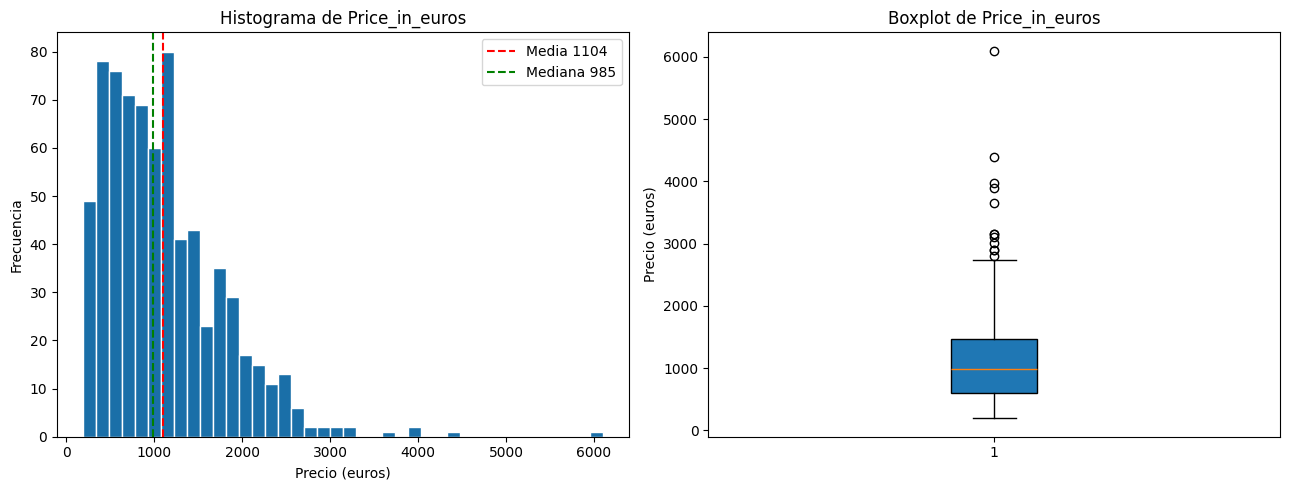

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histograma
axes[0].hist(y_train, bins=40, color="#1a6fa8", edgecolor="white")
axes[0].axvline(y_train.mean(),   color="red",   ls="--", label=f"Media {y_train.mean():.0f}")
axes[0].axvline(y_train.median(), color="green", ls="--", label=f"Mediana {y_train.median():.0f}")
axes[0].set_title("Histograma de Price_in_euros")
axes[0].set_xlabel("Precio (euros)")
axes[0].set_ylabel("Frecuencia")
axes[0].legend()

# Boxplot
axes[1].boxplot(y_train, patch_artist=True)
axes[1].set_title("Boxplot de Price_in_euros")
axes[1].set_ylabel("Precio (euros)")

plt.tight_layout()
plt.show()

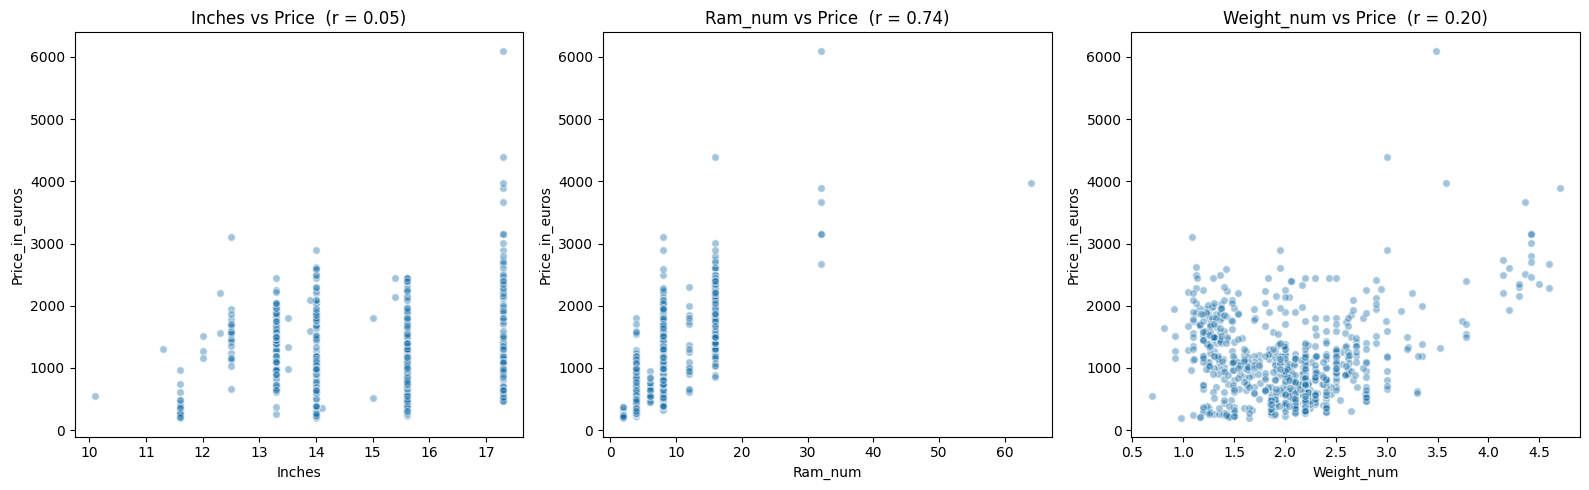

In [13]:
eda = X_train.copy()
eda['Ram_num'] = eda['Ram'].str.replace('GB', '', regex=False).astype(int)
eda['Weight_num'] = eda['Weight'].str.replace('kg', '', regex=False).astype(float)
eda['Price'] = y_train

numericas = ['Inches', 'Ram_num', 'Weight_num']

eda[numericas + ['Price']].corr()['Price'].sort_values(ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, numericas):
    ax.scatter(eda[col], eda['Price'], alpha=0.4, color="#1a6fa8", edgecolor="white", s=30)
    r = eda[col].corr(eda['Price'])
    ax.set_title(f"{col} vs Price  (r = {r:.2f})")
    ax.set_xlabel(col)
    ax.set_ylabel("Price_in_euros")

plt.tight_layout()
plt.show()

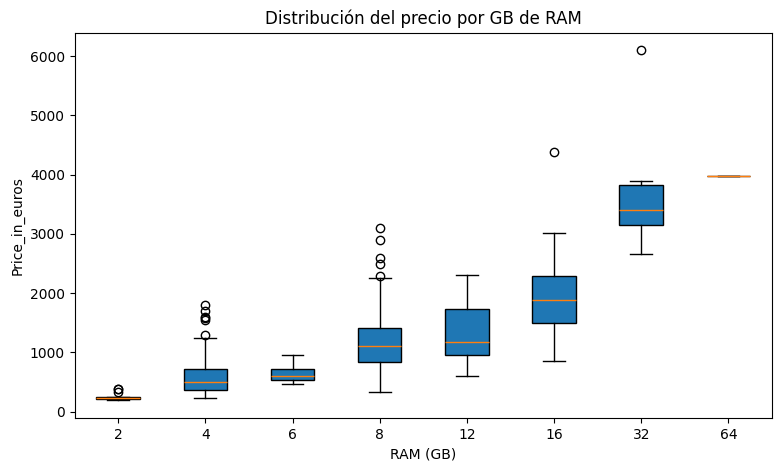

In [14]:
plt.figure(figsize=(9, 5))
niveles = sorted(eda['Ram_num'].unique())
datos   = [eda.loc[eda['Ram_num'] == n, 'Price'] for n in niveles]

plt.boxplot(datos, tick_labels=niveles, patch_artist=True)
plt.title("Distribución del precio por GB de RAM")
plt.xlabel("RAM (GB)")
plt.ylabel("Price_in_euros")
plt.show()

In [15]:
# Aplicamos el feature engineering a train y test por separado
X_train_fe = feature_engineering(X_train)
X_test_fe  = feature_engineering(X_test)

In [16]:
# One-Hot para las categóricas (fit SOLO en train, transform en ambos)
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
ohe.fit(X_train_fe[cat])
cat_cols = ohe.get_feature_names_out(cat)

cat_train_df = pd.DataFrame(ohe.transform(X_train_fe[cat]), columns=cat_cols, index=X_train_fe.index)
cat_test_df  = pd.DataFrame(ohe.transform(X_test_fe[cat]),  columns=cat_cols, index=X_test_fe.index)

X_train_final = pd.concat([X_train_fe[num], cat_train_df], axis=1)
X_test_final  = pd.concat([X_test_fe[num],  cat_test_df],  axis=1)

print("Shape train:", X_train_final.shape)
print("Shape test :", X_test_final.shape)

Shape train: (729, 58)
Shape test : (183, 58)


## 4. Modelado

### 4.1 Entrenamiento

In [17]:
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_final, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

### 4.2 Métricas

Recuerda que en la competición se evalúa con **RMSE**.

In [18]:
pred = rf.predict(X_test_final)
rmse = root_mean_squared_error(y_test, pred)
r2   = r2_score(y_test, pred)

print(f"RMSE: {rmse:.2f} euros")
print(f"R2  : {r2:.4f}")

RMSE: 339.11 euros
R2  : 0.7925


### 4.3 Optimización (up to you 🫰🏻)

In [19]:
# X_train_final, X_test_final ya construidos (numéricas + One-Hot)
y_train_log = np.log1p(y_train)

# --- Rejilla de hiperparámetros ---
param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 1.0]
}

rf = RandomForestRegressor(random_state=42, n_jobs=-1)

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',  # RMSE en espacio log
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train_final, y_train_log)

print("Mejores hiperparámetros:")
print(grid.best_params_)
print(f"\nMejor RMSE (CV, en log): {-grid.best_score_:.4f}")

# --- Evaluar el mejor modelo en test, en euros ---
best_rf = grid.best_estimator_
pred_euros = np.expm1(best_rf.predict(X_test_final))

rmse = root_mean_squared_error(y_test, pred_euros)
r2   = r2_score(y_test, pred_euros)
print(f"\n--- TEST (en euros) ---")
print(f"RMSE: {rmse:.2f} euros")
print(f"R2  : {r2:.4f}")

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Mejores hiperparámetros:
{'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}

Mejor RMSE (CV, en log): 0.2064

--- TEST (en euros) ---
RMSE: 321.98 euros
R2  : 0.8129


### 4.4 Validación cruzada (medición fiable)

Un único split 80-20 da un RMSE con mucha varianza: según qué portátiles caros caigan en test, el error sube o baja varias decenas de euros. Para medir de forma fiable usamos **cross-validation de 5 folds** sobre todo el conjunto.

Montamos el flujo completo como `Pipeline` (One-Hot + modelo) envuelto en `TransformedTargetRegressor`, que aplica `log1p` al entrenar y `expm1` al predecir **dentro de cada fold**, sin fuga de datos. La semilla fija (`random_state=42`) garantiza que todos los modelos se evalúen sobre las mismas particiones, para comparar de forma justa.

> 📏 Esta CV es nuestra **vara de medir**: cualquier cambio futuro (otro modelo, más features) solo cuenta como mejora real si baja la media de forma clara respecto a la desviación.

In [20]:
# Datos con feature engineering aplicado a todo el conjunto
df_fe_cv = feature_engineering(df)
X_cv = df_fe_cv[num + cat]
y_cv = df_fe_cv['Price_in_euros']

# Pipeline: One-Hot de categóricas + RandomForest, con target en log
preprocesado = ColumnTransformer(
    [('cat', OneHotEncoder(handle_unknown='ignore'), cat)],
    remainder='passthrough'
)

rf_cv = RandomForestRegressor(
    n_estimators=500, max_depth=20, max_features='sqrt',
    min_samples_leaf=1, min_samples_split=2, random_state=42, n_jobs=-1
)

pipe = Pipeline([('prep', preprocesado), ('model', rf_cv)])

# log1p al entrenar / expm1 al predecir, dentro de cada fold
modelo_cv = TransformedTargetRegressor(regressor=pipe, func=np.log1p, inverse_func=np.expm1)

# RMSE en euros como métrica de CV
rmse_scorer = make_scorer(root_mean_squared_error, greater_is_better=False)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

scores = -cross_val_score(modelo_cv, X_cv, y_cv, scoring=rmse_scorer, cv=kf, n_jobs=-1)

print("RMSE por fold:", np.round(scores, 2))
print(f"RMSE CV media: {scores.mean():.2f} euros")
print(f"Desv. std    : {scores.std():.2f} euros")
print(f"\n>>> REFERENCIA: {scores.mean():.0f} +/- {scores.std():.0f} euros <<<")

RMSE por fold: [321.18 251.33 291.32 218.98 372.83]
RMSE CV media: 291.13 euros
Desv. std    : 53.60 euros

>>> REFERENCIA: 291 +/- 54 euros <<<


## 5. Reentrenamiento sobre todos los datos de `train.csv`

Una vez afinado el modelo, reentrenamos con **todos** los datos disponibles antes de predecir sobre `test.csv`.

> ¿Por qué? El split anterior era solo para validar localmente. Para la submission final queremos aprovechar el 100% de los datos de entrenamiento.

In [21]:
# Aplicamos el feature engineering a TODO df
df_fe = feature_engineering(df)

# One-Hot reajustado con todo df
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
ohe.fit(df_fe[cat])
cat_cols = ohe.get_feature_names_out(cat)

cat_df = pd.DataFrame(ohe.transform(df_fe[cat]), columns=cat_cols, index=df_fe.index)
X_full = pd.concat([df_fe[num], cat_df], axis=1)

# Target normalizado
y_full_log = np.log1p(df_fe['Price_in_euros'])

# Mejores hiperparámetros obtenidos del GridSearchCV (celda anterior):
# {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1,
#  'min_samples_split': 2, 'n_estimators': 500}
rf_final = RandomForestRegressor(
    n_estimators=500,
    max_depth=20,
    max_features='sqrt',
    min_samples_leaf=1,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)
rf_final.fit(X_full, y_full_log)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsampl

---
# PARTE 2: Predicción y submission

Una vez tengas el modelo listo, toca predecir sobre `test.csv` y generar el archivo de submission.

## 6. Carga los datos de `test.csv`

In [22]:
X_pred = pd.read_csv('./data/test.csv', encoding='latin-1')
X_pred.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight
0,209,Lenovo,Legion Y520-15IKBN,Gaming,15.6,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16GB,512GB SSD,Nvidia GeForce GTX 1060,No OS,2.4kg
1,1281,Acer,Aspire ES1-531,Notebook,15.6,1366x768,Intel Celeron Dual Core N3060 1.6GHz,4GB,500GB HDD,Intel HD Graphics 400,Linux,2.4kg
2,1168,Lenovo,V110-15ISK (i3-6006U/4GB/1TB/No,Notebook,15.6,1366x768,Intel Core i3 6006U 2.0GHz,4GB,1TB HDD,Intel HD Graphics 520,No OS,1.9kg
3,1231,Dell,Inspiron 7579,2 in 1 Convertible,15.6,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,Windows 10,2.191kg
4,1020,HP,ProBook 640,Notebook,14.0,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,4GB,256GB SSD,Intel HD Graphics 620,Windows 10,1.95kg


## 7. Replica el procesado en `test.csv`

> ⚠️ Usa `.transform()`, **nunca `.fit_transform()`** sobre los datos de test.
>
> Lo único que **no puedes hacer** es eliminar filas.

In [23]:
# Aplicamos EXACTAMENTE el mismo feature engineering (no elimina filas)
X_pred_fe = feature_engineering(X_pred)

# One-Hot SOLO con transform (reutiliza el ohe ajustado en df)
cat_pred = pd.DataFrame(
    ohe.transform(X_pred_fe[cat]),
    columns=cat_cols,
    index=X_pred_fe.index
)

# Matriz final de test
X_pred_final = pd.concat([X_pred_fe[num], cat_pred], axis=1)

print("Shape test procesado:", X_pred_final.shape)

Shape test procesado: (391, 58)


## 8. Genera la submission

### 8.1 ¿Qué formato espera Kaggle?

In [24]:
sample = pd.read_csv('./data/sample_submission.csv', encoding='latin-1')
sample.head()

,laptop_ID,Price_in_euros
0,209,1949.1
1,1281,805.0
2,1168,1101.0
3,1231,1293.8
4,1020,1832.6


### 8.2 Crea tu submission

In [25]:
submission = pd.DataFrame({
    'laptop_ID': X_pred['laptop_ID'],
    'Price_in_euros': np.expm1(rf_final.predict(X_pred_final))
})
submission

,laptop_ID,Price_in_euros
0,209,1433.673119
1,1281,290.752666
2,1168,399.158296
3,1231,917.043694
4,1020,928.098220
...,...,...
386,820,2148.369601
387,948,959.278351
388,483,1609.651613
389,1017,845.496961


### 8.3 Chequeador

Pásale el chequeador antes de subir a Kaggle. Si todo está bien, guardará el CSV automáticamente con un nombre único.

In [26]:
def checker(df_to_submit, sample, filename=None):
    """
    Valida que tu submission tenga la forma requerida por Kaggle.
    Si es correcta, guarda el CSV listo para subir.
    Si no, lee el mensaje de error y corrígelo.
    """
    if df_to_submit.shape != sample.shape:
        print(' Shape incorrecto.')
        print(f'   Tu submission: {df_to_submit.shape} | Esperado: {sample.shape}')
        print('   Revisa que no hayas borrado filas del test ni añadido/quitado columnas.')
        return

    if not (df_to_submit.columns == sample.columns).all():
        print(' Nombres de columnas incorrectos.')
        print(f'   Tus columnas:       {list(df_to_submit.columns)}')
        print(f'   Columnas esperadas: {list(sample.columns)}')
        return

    if not (df_to_submit['laptop_ID'] == sample['laptop_ID']).all():
        print(' Los IDs no coinciden con sample_submission. Revisa que no hayas reordenado el test.csv.')
        return

    if filename is None:
        from datetime import datetime
        timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
        filename = f'submission_{timestamp}.csv'

    df_to_submit.to_csv(filename, index=False)
    print(f" ¡Todo correcto! Submission guardada como '{filename}'. ¡A Kaggle!")

In [27]:
checker(submission, sample)

 ¡Todo correcto! Submission guardada como 'submission_20260628_155407.csv'. ¡A Kaggle!
